In [ ]:
import pandas as pd
print ("Pandas importado com sucesso!")


Pandas importado com sucesso!


In [ ]:
# Carregando a base de dados que já mora dentro do próprio Google Colab
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

print("Dados carregados direto do sistema do Google.")

Dados carregados direto do sistema do Google.


In [ ]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
# Vamos calcular a correlação entre a renda média e o valor do imóvel
correlacao = df['median_income'].corr(df['median_house_value'])

print(f"A correlação entre a Renda Média e o Valor do Imóvel é de: {correlacao:.2f}")

A correlação entre a Renda Média e o Valor do Imóvel é de: 0.69


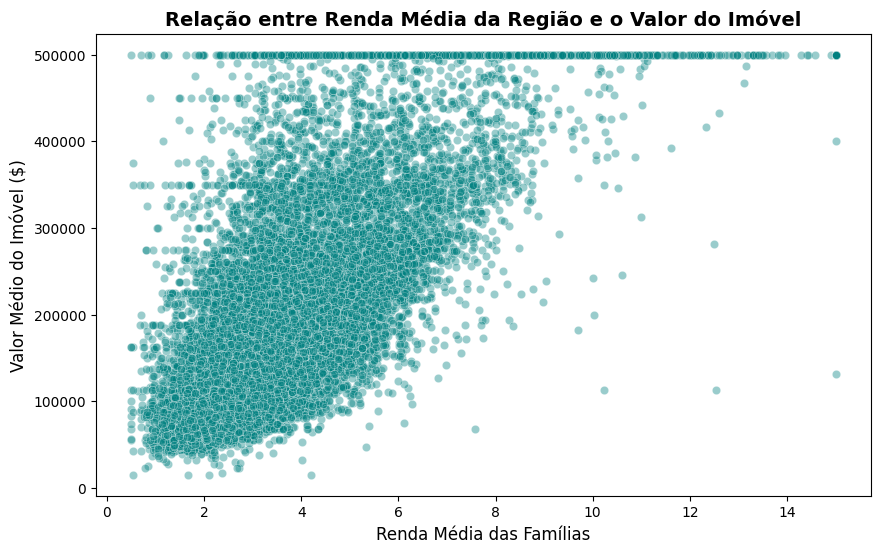

In [ ]:
# Importando as bibliotecas de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo do gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.4, color='teal')

# Colocando títulos organizados
plt.title('Relação entre Renda Média da Região e o Valor do Imóvel', fontsize=14, fontweight='bold')
plt.xlabel('Renda Média das Famílias', fontsize=12)
plt.ylabel('Valor Médio do Imóvel ($)', fontsize=12)

# Exibindo o gráfico na tela
plt.show()

In [ ]:
# Criando uma nova tabela filtrada (removendo o teto de 500k)
df_limpo = df[df['median_house_value'] < 500000]

# Vamos ver quantas linhas restaram comparando com o original
print(f"Linhas no banco original: {df.shape[0]}")
print(f"Linhas no banco limpo: {df_limpo.shape[0]}")

Linhas no banco original: 17000
Linhas no banco limpo: 16164


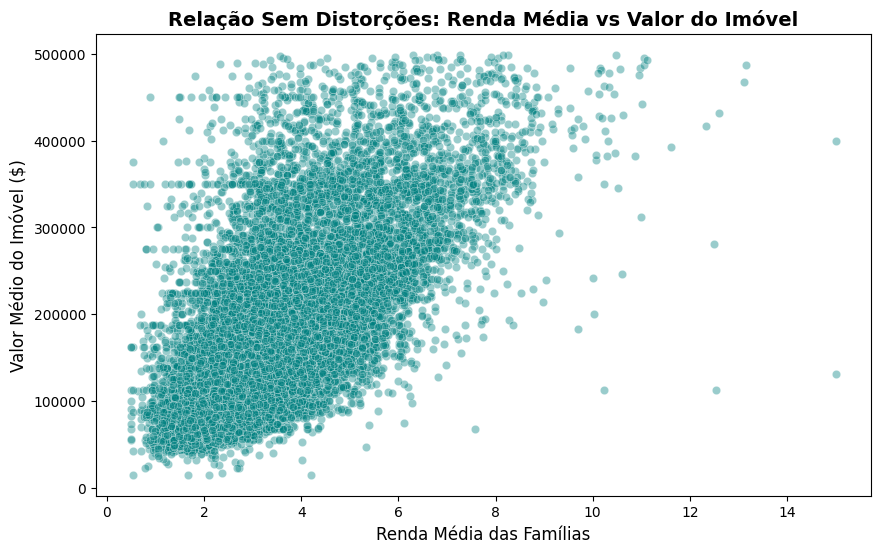

In [ ]:
plt.figure(figsize=(10, 6))

# Repare que agora usamos 'data=df_limpo'
sns.scatterplot(data=df_limpo, x='median_income', y='median_house_value', alpha=0.4, color='teal')

plt.title('Relação Sem Distorções: Renda Média vs Valor do Imóvel', fontsize=14, fontweight='bold')
plt.xlabel('Renda Média das Famílias', fontsize=12)
plt.ylabel('Valor Médio do Imóvel ($)', fontsize=12)

plt.show()

In [ ]:
# Calculando a correlação real na base limpa
correlacao_limpa = df_limpo['median_income'].corr(df_limpo['median_house_value'])

print(f"A correlação real (sem distorções) é de: {correlacao_limpa:.2f}")

A correlação real (sem distorções) é de: 0.65


In [ ]:
# Criando uma nova coluna: média de quartos por família/lar
df_limpo['quartos_por_familia'] = df_limpo['total_bedrooms'] / df_limpo['households']

# Vamos ver a média geral dessa nova métrica
media_quartos = df_limpo['quartos_por_familia'].mean()
print(f"Em média, as famílias dessa base de dados vivem em lares com {media_quartos:.2f} quartos.")

Em média, as famílias dessa base de dados vivem em lares com 1.10 quartos.


/tmp/ipykernel_2271/1694332035.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpo['quartos_por_familia'] = df_limpo['total_bedrooms'] / df_limpo['households']


Correlação entre Quartos por Família e Valor do Imóvel: -0.06



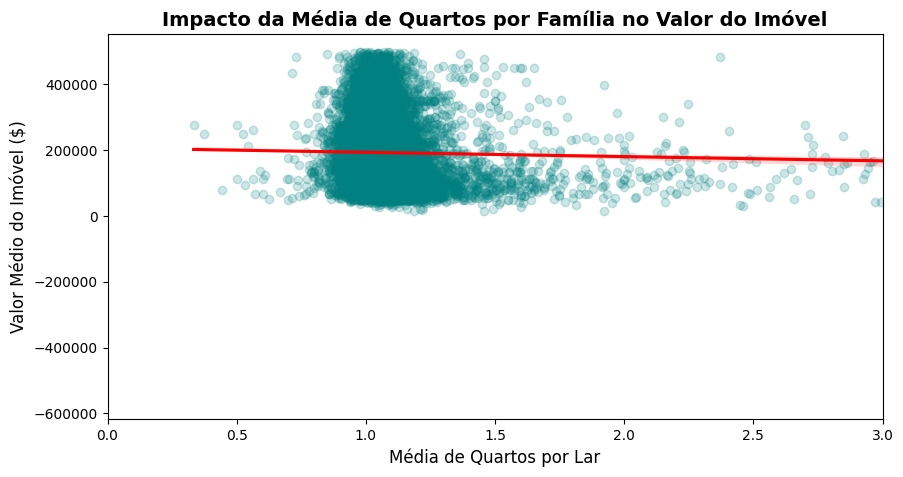

In [ ]:
# Calculando a correlação com a nova métrica
correlacao_quartos = df_limpo['quartos_por_familia'].corr(df_limpo['median_house_value'])
print(f"Correlação entre Quartos por Família e Valor do Imóvel: {correlacao_quartos:.2f}\n")

# Gerando um gráfico rápido para ver a tendência
plt.figure(figsize=(10, 5))
sns.regplot(data=df_limpo, x='quartos_por_familia', y='median_house_value',
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Impacto da Média de Quartos por Família no Valor do Imóvel', fontsize=14, fontweight='bold')
plt.xlabel('Média de Quartos por Lar', fontsize=12)
plt.ylabel('Valor Médio do Imóvel ($)', fontsize=12)
plt.xlim(0, 3) # Limitando o eixo X para focar onde está a maioria dos dados

plt.show()

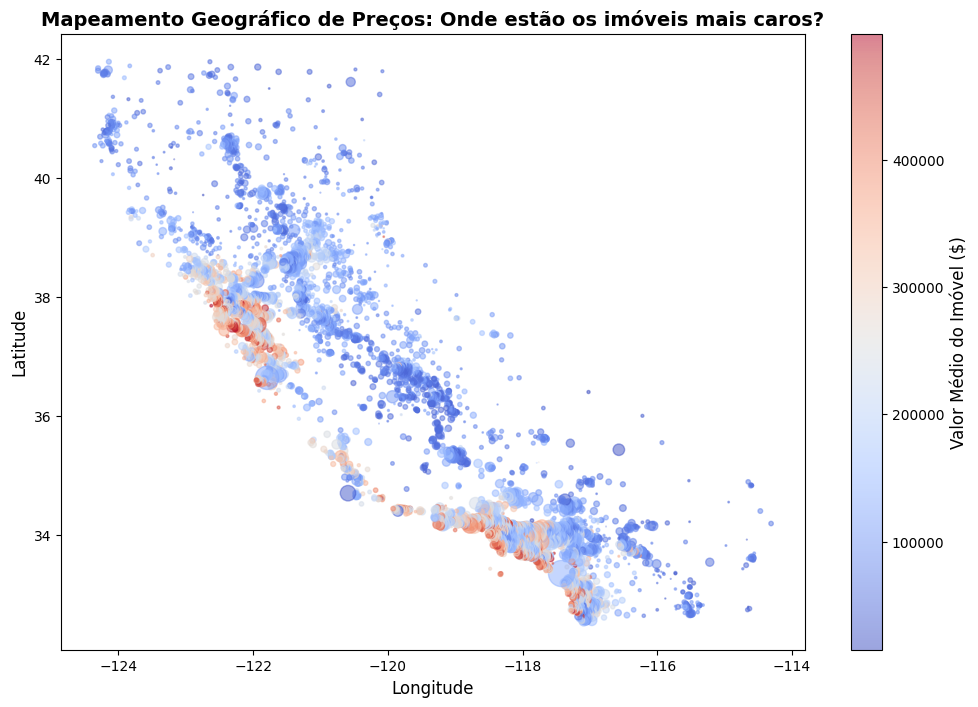

In [ ]:
# Criando um mapa com base nas coordenadas geográficas
plt.figure(figsize=(12, 8))

# O 'c' define que a cor do ponto depende do valor do imóvel (median_house_value)
# O 'cmap' usa a paleta 'coolwarm' (azul para barato, vermelho para muito caro)
grafico_mapa = plt.scatter(data=df_limpo, x='longitude', y='latitude',
                           c='median_house_value', cmap='coolwarm',
                           alpha=0.5, s=df_limpo['population']/100)

# Adicionando uma barra de cores lateral para servir de legenda
cbar = plt.colorbar(grafico_mapa)
cbar.set_label('Valor Médio do Imóvel ($)', fontsize=12)

# Títulos e eixos
plt.title('Mapeamento Geográfico de Preços: Onde estão os imóveis mais caros?', fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

plt.show()